In [1]:
import sys
print(sys.executable)

/Users/kartikayluthra/Desktop/multus/msc_env/bin/python


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import pandas as pd

In [3]:
def shape_analysis(path):
    image = cv.imread(path)
    print(image.shape)

shape_analysis('/Users/kartikayluthra/Desktop/multus/data/images/AD-E1-t28.tif')

(1992, 1992, 3)


In [4]:
def is_grayscale(path):
    image = cv.imread(path)
    b, g, r = cv.split(image)

    is_gray = np.allclose(b, g) and np.allclose(g, r)

    print(is_gray)

is_grayscale('/Users/kartikayluthra/Desktop/multus/data/images/AD-E1-t28.tif')

True


/var/folders/1z/npbdg1px16jdq9vjn93zzfcm0000gn/T/ipykernel_55608/4247684697.py:4: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.ravel(),256,[0,256]);


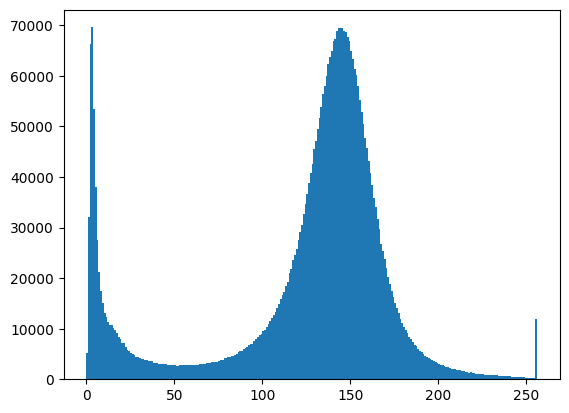

In [41]:
def histogram(path):
    img = cv.imread(path, cv.IMREAD_GRAYSCALE)
    assert img is not None, "file could not be read, check with os.path.exists()"
    plt.hist(img.ravel(),256,[0,256]); 
    plt.savefig('/Users/kartikayluthra/Desktop/multus/plots' +'AD_E1_t28histogram.png')
    plt.show()
    
histogram('/Users/kartikayluthra/Desktop/multus/data/images/AD-E1-t28.tif')

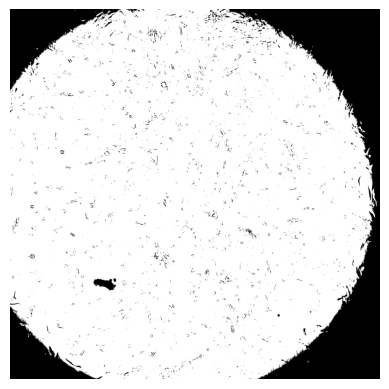

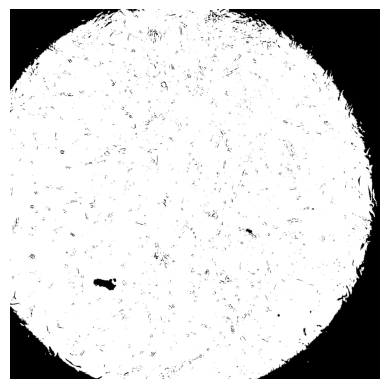

465

In [42]:
import cv2 as cv
import matplotlib.pyplot as plt
from scipy import ndimage as sho
from skimage.feature import peak_local_max
from skimage.segmentation import watershed

def thresholding_clean_counting(filepath):
    image = cv.imread(filepath)

    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

    _, binary_mask = cv.threshold(
        gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU
    )

    
    plt.imshow(binary_mask, cmap='gray')
    plt.axis('off')
    plt.savefig('/Users/kartikayluthra/Desktop/multus/plots' +'otsu_thresholding.png')
    plt.show()
    
    kernel = np.ones((3,3), np.uint8)
    clean_mask = cv.morphologyEx(binary_mask, cv.MORPH_OPEN, kernel)
    
    plt.imshow(clean_mask, cmap='gray')
    plt.axis('off')
    plt.savefig('/Users/kartikayluthra/Desktop/multus/plots' +'clean_mask.jpg')
    plt.show()
    

    if np.mean(clean_mask) > 127:
        clean_mask = cv.bitwise_not(clean_mask)

    # 2. FILL HOLES
    filled_mask = sho.binary_fill_holes(clean_mask).astype(np.uint8) * 255

    # 3. DISTANCE TRANSFORM
    dist_transform = cv.distanceTransform(filled_mask, cv.DIST_L2, 5)

    # 4. FIND PEAKS
    # Increase 'min_distance' if you are getting too many markers per cell
    # Decrease it if you are missing cells
    local_maxi = peak_local_max(dist_transform, min_distance=10, labels=filled_mask)

    # 5. WATERSHED
    markers = sho.label(np.zeros_like(filled_mask))[0]
    for i, pt in enumerate(local_maxi):
        markers[pt[0], pt[1]] = i + 1

    # Apply watershed on the INVERSE of distance transform
    labels = watershed(-dist_transform, markers, mask=filled_mask)

    # 6. FILTER AND COUNT
    num_labels, labels_im, stats, centroids = cv.connectedComponentsWithStats(labels.astype(np.uint8))

    min_cell_area = 20 # Adjust this to filter out tiny noise
    final_counts = 0
    for i in range(1, num_labels):
        area = stats[i, cv.CC_STAT_AREA]
        if area > min_cell_area:
            final_counts += 1
    
    return final_counts

    #print(f"Corrected MSC count: {final_counts}")
    



thresholding_clean_counting('/Users/kartikayluthra/Desktop/multus/data/images/AD-E1-t28.tif')

In [20]:
all_data = []
def main():
    folder_path = '/Users/kartikayluthra/Desktop/multus/data/images'


    for image_name in os.listdir(folder_path):
        # 1. Standard file filters
        if not image_name.endswith('.tif') or image_name.startswith('.'):
            continue
            
        filepath = os.path.join(folder_path, image_name)
        
        # 2. Handle the 'noGrowth' files specifically
        if 'noGrowth' in image_name:
            print(f"Processing Control Image: {image_name}")
            current_count = thresholding_clean_counting(filepath)
            
            all_data.append({
                'Cell_Line': 'CONTROL',
                'Well': 'N/A',
                'Timestamp': 0,
                'Count': current_count,
                'Status': 'No Growth observed',
                'Filename': image_name
            })
            continue # Skip the rest of the parsing for this file

        # 3. Process standard images
        name_no_ext = image_name.replace('.tif', '')
        parts = name_no_ext.split('-') 

        if len(parts) >= 3:
            current_count = thresholding_clean_counting(filepath)
            
            # Use .lower() to handle 'T28' vs 't28'
            timestamp_str = parts[2].lower().replace('t', '')
            
            all_data.append({
                'Cell_Line': parts[0],
                'Well': parts[1],
                'Timestamp': int(timestamp_str),
                'Count': current_count,
                'Status': 'Healthy',
                'Filename': image_name
            })
    
    df = pd.DataFrame(all_data)
    print(df.sort_values(by=['Cell_Line', 'Timestamp']))
    return df

if __name__ == "__main__":
    df_results = main()

Processing Control Image: noGrowth1.tif
Processing Control Image: noGrowth3.tif
Processing Control Image: noGrowth2.tif
Processing Control Image: noGrowth4.tif
   Cell_Line Well  Timestamp  Count              Status        Filename
1         AD   G5          4    223             Healthy   AD-G5-t04.tif
21        AD   E1          4    102             Healthy   AD-E1-t04.tif
2         AD   G5         10    248             Healthy   AD-G5-t10.tif
20        AD   E1         10    137             Healthy   AD-E1-t10.tif
8         AD   G5         16    263             Healthy   AD-G5-t16.tif
17        AD   E1         16    131             Healthy   AD-E1-t16.tif
25        AD   E1         22    267             Healthy   AD-E1-t22.tif
36        AD   G5         22   1194             Healthy   AD-G5-t22.tif
12        AD   G5         28   2489             Healthy   AD-G5-t28.tif
15        AD   E1         28    465             Healthy   AD-E1-t28.tif
24        AD   E1         34    657             

In [21]:
df = pd.DataFrame(all_data)
df.head()

,Cell_Line,Well,Timestamp,Count,Status,Filename
0,UC,H7,10,49,Healthy,UC-H7-t10.tif
1,AD,G5,4,223,Healthy,AD-G5-t04.tif
2,AD,G5,10,248,Healthy,AD-G5-t10.tif
3,UC,H7,4,35,Healthy,UC-H7-t04.tif
4,BM,C1,22,174,Healthy,BM-C1-t22.tif


   Cell_Line Well  Timestamp  Count   Status       Filename
15        AD   E1         28    465  Healthy  AD-E1-t28.tif
17        AD   E1         16    131  Healthy  AD-E1-t16.tif
20        AD   E1         10    137  Healthy  AD-E1-t10.tif
21        AD   E1          4    102  Healthy  AD-E1-t04.tif
24        AD   E1         34    657  Healthy  AD-E1-t34.tif
25        AD   E1         22    267  Healthy  AD-E1-t22.tif


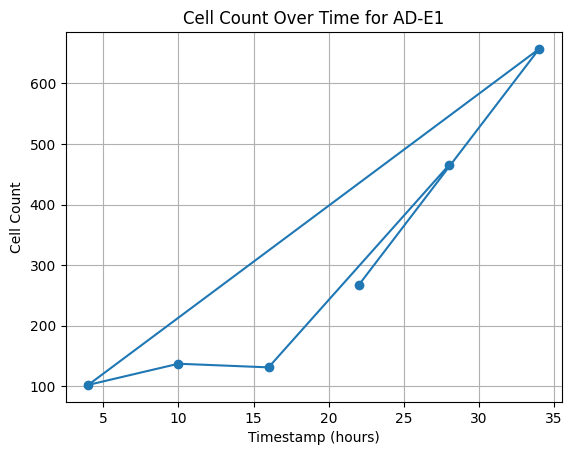

In [43]:

df_AD_E1 = df[(df['Cell_Line'] == 'AD') & (df['Well'] == 'E1')]
print(df_AD_E1)
plt.plot(df_AD_E1['Timestamp'], df_AD_E1['Count'], marker='o')
plt.title('Cell Count Over Time for AD-E1')
plt.xlabel('Timestamp (hours)')
plt.ylabel('Cell Count')
plt.grid()
plt.savefig('/Users/kartikayluthra/Desktop/multus/plots' +'AD_E1.png')
plt.show()


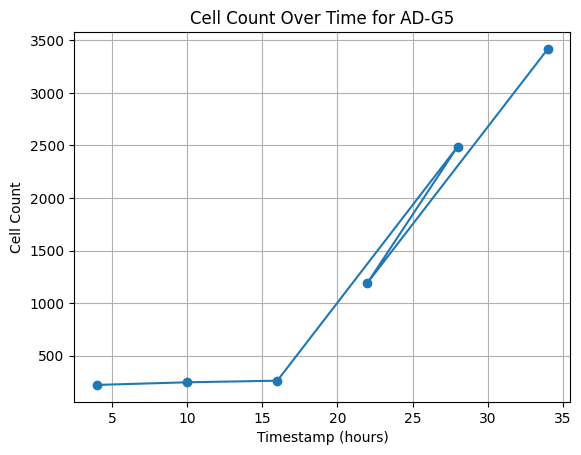

In [44]:
df_g5 = df[(df['Cell_Line'] == 'AD') & (df['Well'] == 'G5')]
plt.plot(df_g5['Timestamp'], df_g5['Count'], marker='o')
plt.title('Cell Count Over Time for AD-G5')
plt.xlabel('Timestamp (hours)')
plt.ylabel('Cell Count')
plt.grid()
plt.savefig('/Users/kartikayluthra/Desktop/multus/plots' +'AD_G5.png')
plt.show()  


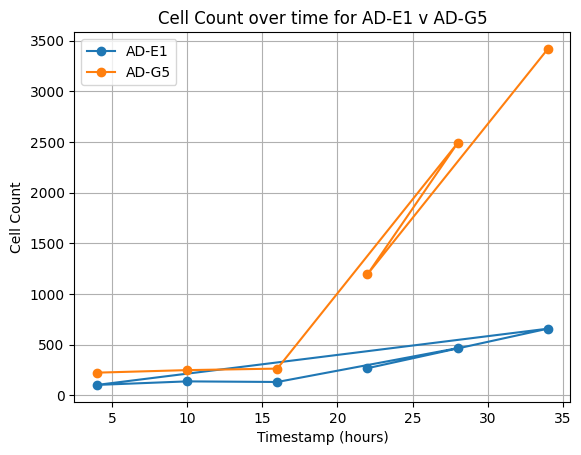

In [45]:
plt.plot(df_AD_E1['Timestamp'], df_AD_E1['Count'], marker='o')
plt.plot(df_g5['Timestamp'], df_g5['Count'], marker='o')
plt.title('Cell Count over time for AD-E1 v AD-G5')
plt.xlabel('Timestamp (hours)')
plt.ylabel('Cell Count')
plt.legend(['AD-E1', 'AD-G5'])
plt.grid()
plt.savefig('/Users/kartikayluthra/Desktop/multus/plots' +'AD_E1_v_G5.png')
plt.show()


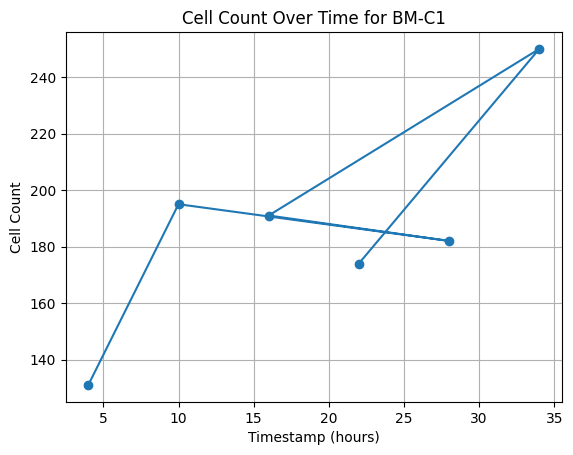

In [46]:
df_bm_c1 = df[(df['Cell_Line'] == 'BM') & (df['Well'] == 'C1')]
plt.plot(df_bm_c1['Timestamp'], df_bm_c1['Count'], marker='o')
plt.title('Cell Count Over Time for BM-C1')
plt.xlabel('Timestamp (hours)')
plt.ylabel('Cell Count')
plt.grid()
plt.savefig('/Users/kartikayluthra/Desktop/multus/plots' +'BM_C1.png')
plt.show()


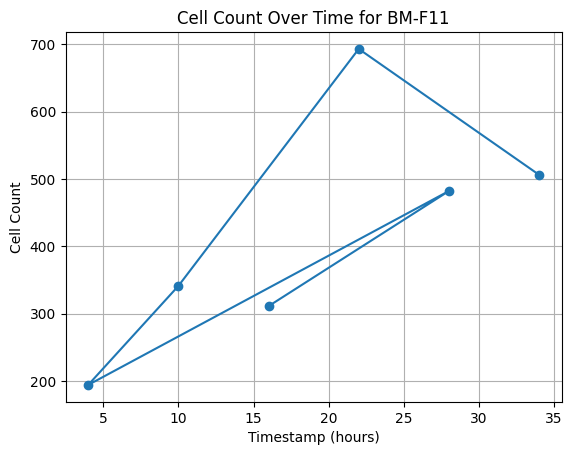

In [47]:
df_bm_f11 = df[(df['Cell_Line'] == 'BM') & (df['Well'] == 'F11')]
plt.plot(df_bm_f11['Timestamp'], df_bm_f11['Count'], marker='o')
plt.title('Cell Count Over Time for BM-F11')
plt.xlabel('Timestamp (hours)')
plt.ylabel('Cell Count')
plt.grid()
plt.savefig('/Users/kartikayluthra/Desktop/multus/plots' +'BM_C1_v_F11.png')
plt.show()
